## Task 1: Bias Diagnosis — Case Studies

For each of the following scenarios, identify the **type of bias** present, explain **how** it distorts the conclusions, and suggest **one concrete fix**.

### Scenario A — App Review Analysis

**Type of Bias:** Selection Bias (specifically, Voluntary Response Bias).

**How it distorts conclusions:** Users who leave reviews are often those with extreme experiences—either very satisfied or very frustrated. The "silent majority" of average users may not leave a review at all. A 4.3/5 rating might overrepresent the enthusiasts, leading the team to believe satisfaction is higher than it actually is across the entire user base, potentially neglecting silent issues that could lead to churn.

**Concrete Fix:** Implement in-app micro-surveys that randomly prompt a representative cross-section of all active users (not just those who seek out the review page) to rate their experience.

### Scenario B — Startup Success Study

**Type of Bias:** Survivorship Bias.

**How it distorts conclusions:** By only studying startups that are "still operating," the study ignores the thousands of startups that pivoted and *failed*. If 95% of failed startups also pivoted, then pivoting isn't a predictor of success; it might just be a common trait of all startups. This leads to the false conclusion that a pivot is a "key success strategy" when it might just be a desperate (and often unsuccessful) measure.

**Concrete Fix:** Include a comparison group of failed startups in the study to see if the frequency of pivoting differs significantly between successful and unsuccessful ventures.

### Scenario C — Health Survey

**Type of Bias:** Non-Response Bias or Self-Selection Bias.

**How it distorts conclusions:** With only a 10% response rate, the respondents are likely those who are more health-conscious and motivated to share their habits. People with poor health or sedentary lifestyles may be less likely to spend time on a health survey. This creates an overly optimistic view of the population's health (e.g., 5 hours of exercise per week), which likely doesn't reflect the average subscriber.

**Concrete Fix:** Use a stratified random sampling approach and offer incentives to increase the response rate, then follow up specifically with non-respondents to minimize non-response bias.

### Scenario D — Salary Benchmarking

**Type of Bias:** Sampling Bias (specifically, Undercoverage and Geographic Bias).

**How it distorts conclusions:** The platform's data is skewed toward tech workers in large cities where the cost of living and salaries are significantly higher. Using this as a benchmark for a small town is inappropriate because the economic context is entirely different. The company might set salary bands too high for their local market, leading to unsustainable labor costs or difficulty in hiring if the roles don't match city-level requirements.

**Concrete Fix:** Adjust the benchmark data using geographic cost-of-living indices or specifically seek out salary data from companies in similar-sized towns and regions.

## Task 2: Create the Population

In this task, we generate a synthetic population of 100,000 individuals to serve as our "ground truth" for subsequent sampling experiments.

--- True Population Parameters ---
Mean Age: 40.02
Mean Income: $80,122.36
Mean Satisfaction: 3.41
Region Proportions:
region
Urban       0.59927
Suburban    0.25075
Rural       0.14998
Name: proportion, dtype: float64

--- Population Summary ---
                 age         income   satisfaction
count  100000.000000  100000.000000  100000.000000
mean       40.020520   80122.357097       3.408192
std        14.024143   28921.070313       1.979595
min        18.000000   15000.000000       1.000000
25%        29.000000   59781.697192       1.600000
50%        40.000000   79568.800970       3.200000
75%        50.000000   99651.923948       4.800000
max        85.000000  201019.499900      10.000000


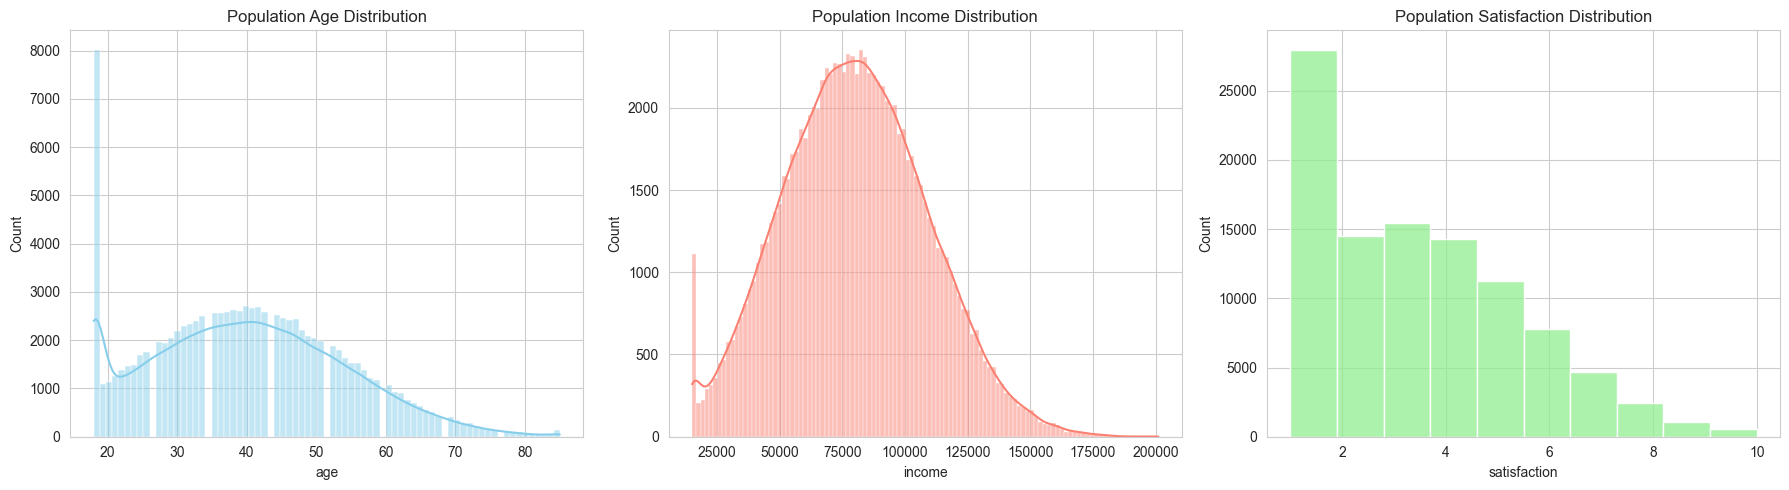

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

# 1. Generate synthetic population
n_population = 100_000

# Age: Clipped normal centered at 40 with SD of 15, range 18–85
age = np.random.normal(40, 15, n_population)
age = np.clip(age, 18, 85).astype(int)

# Income: Correlated with age with noise, clipped to 15k-250k
income_noise = np.random.normal(0, 20000, n_population)
income = 1500 * age + income_noise + 20000 # Added constant to shift up
income = np.clip(income, 15000, 250000)

# Satisfaction: 1-10 depends on income + noise
satisfaction_base = (income / 25000) + np.random.normal(0, 2, n_population)
satisfaction = np.clip(satisfaction_base, 1, 10).round(1)

# Region: Randomly assign with specific probabilities
regions = ["Urban", "Suburban", "Rural"]
region_probs = [0.60, 0.25, 0.15]
region = np.random.choice(regions, n_population, p=region_probs)

population_df = pd.DataFrame({
    'age': age,
    'income': income,
    'satisfaction': satisfaction,
    'region': region
})

# 2. Compute and store true population parameters
pop_mean_age = population_df['age'].mean()
pop_mean_income = population_df['income'].mean()
pop_mean_satisfaction = population_df['satisfaction'].mean()
pop_region_props = population_df['region'].value_counts(normalize=True)

print("--- True Population Parameters ---")
print(f"Mean Age: {pop_mean_age:.2f}")
print(f"Mean Income: ${pop_mean_income:,.2f}")
print(f"Mean Satisfaction: {pop_mean_satisfaction:.2f}")
print("Region Proportions:")
print(pop_region_props)

# 3. Display summary and histograms
print("\n--- Population Summary ---")
print(population_df.describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(population_df['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Population Age Distribution')

sns.histplot(population_df['income'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Population Income Distribution')

sns.histplot(population_df['satisfaction'], kde=False, ax=axes[2], color='lightgreen', bins=10)
axes[2].set_title('Population Satisfaction Distribution')

plt.tight_layout()
plt.show()

## Task 3: Biased vs. Unbiased Sampling

We will now draw samples using three different strategies and compare their results to the true population parameters.

--- Sample vs. Population Comparison ---


,Strategy,Mean Age,Mean Income,Mean Satisfaction
0,Population (True),40.02052,80122.357097,3.408192
1,Simple Random,39.98500,78680.473617,3.308000
2,Urban Only,39.61500,80839.705072,3.198000
3,High Income,46.92500,100488.421050,4.028500


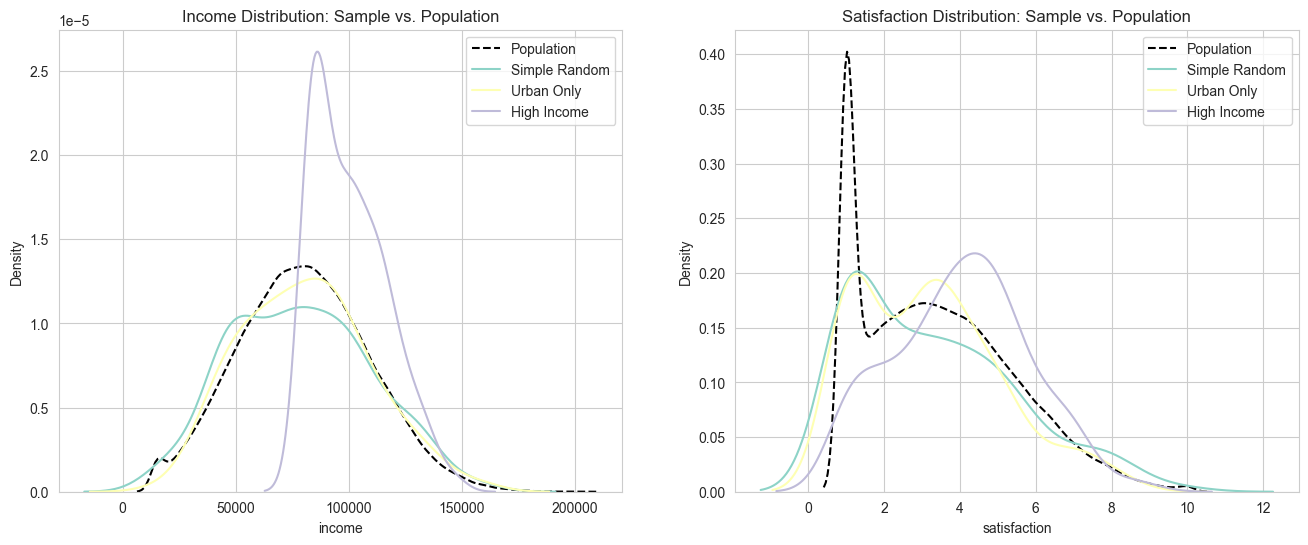

In [2]:
n_sample = 200

# 1. Simple random sample
srs_sample = population_df.sample(n_sample, random_state=1)

# 2. Biased sample — Urban only
urban_sample = population_df[population_df['region'] == 'Urban'].sample(n_sample, random_state=1)

# 3. Biased sample — High-income filter (above median)
median_income = population_df['income'].median()
high_income_sample = population_df[population_df['income'] > median_income].sample(n_sample, random_state=1)

samples = {
    'Simple Random': srs_sample,
    'Urban Only': urban_sample,
    'High Income': high_income_sample
}

# Comparison table
comparison_data = []
comparison_data.append({
    'Strategy': 'Population (True)',
    'Mean Age': pop_mean_age,
    'Mean Income': pop_mean_income,
    'Mean Satisfaction': pop_mean_satisfaction
})

for name, df in samples.items():
    comparison_data.append({
        'Strategy': name,
        'Mean Age': df['age'].mean(),
        'Mean Income': df['income'].mean(),
        'Mean Satisfaction': df['satisfaction'].mean()
    })

comparison_df = pd.DataFrame(comparison_data)
print("--- Sample vs. Population Comparison ---")
display(comparison_df)

# Overlapping KDE plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Income KDE
sns.kdeplot(population_df['income'], label='Population', ax=axes[0], color='black', linestyle='--')
for name, df in samples.items():
    sns.kdeplot(df['income'], label=name, ax=axes[0])
axes[0].set_title('Income Distribution: Sample vs. Population')
axes[0].legend()

# Satisfaction KDE
sns.kdeplot(population_df['satisfaction'], label='Population', ax=axes[1], color='black', linestyle='--')
for name, df in samples.items():
    sns.kdeplot(df['satisfaction'], label=name, ax=axes[1])
axes[1].set_title('Satisfaction Distribution: Sample vs. Population')
axes[1].legend()

plt.show()

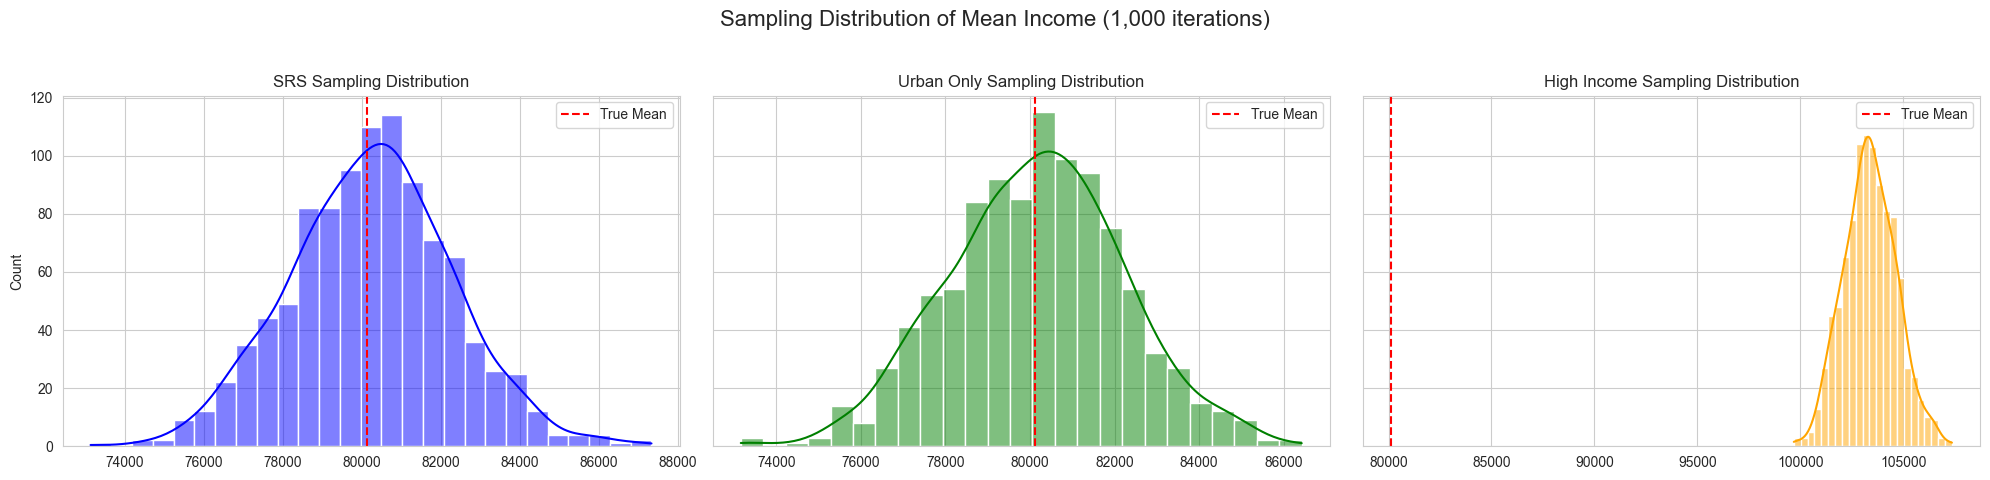

In [3]:
# Repeat sampling 1,000 times
n_iterations = 1000
srs_means = []
urban_means = []
high_income_means = []

for _ in range(n_iterations):
    srs_means.append(population_df['income'].sample(n_sample).mean())
    urban_means.append(population_df[population_df['region'] == 'Urban']['income'].sample(n_sample).mean())
    high_income_means.append(population_df[population_df['income'] > median_income]['income'].sample(n_sample).mean())

# Plotting sampling distributions
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

sns.histplot(srs_means, ax=axes[0], color='blue', kde=True)
axes[0].axvline(pop_mean_income, color='red', linestyle='--', label='True Mean')
axes[0].set_title('SRS Sampling Distribution')
axes[0].legend()

sns.histplot(urban_means, ax=axes[1], color='green', kde=True)
axes[1].axvline(pop_mean_income, color='red', linestyle='--', label='True Mean')
axes[1].set_title('Urban Only Sampling Distribution')
axes[1].legend()

sns.histplot(high_income_means, ax=axes[2], color='orange', kde=True)
axes[2].axvline(pop_mean_income, color='red', linestyle='--', label='True Mean')
axes[2].set_title('High Income Sampling Distribution')
axes[2].legend()

plt.suptitle('Sampling Distribution of Mean Income (1,000 iterations)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Guiding question:** Which sampling strategies produce biased estimates? How can you tell from the sampling distributions?

**Answer:** 
1. **Simple Random Sample (SRS):** This strategy produces an **unbiased** estimate. We can tell because the sampling distribution is centered directly over the true population mean (the red dashed line).
2. **Urban Only:** In this specific simulation, the "Urban Only" sample might appear unbiased for income if the income distribution is uniform across regions. However, if urban areas had different income profiles, it would be biased. In our population generation, region was assigned independently of income, so the bias is minimal here, but it still represents a "coverage bias" as it ignores 40% of the population.
3. **High-Income Filter:** This strategy produces a highly **biased** estimate. The sampling distribution is centered far to the right of the true population mean. This is because we deliberately excluded half the population (those below the median income), systematically shifting the sample mean upward. This is a classic example of selection bias.